# Credit Risk EDA - Home Credit Default Risk

**Goal:** Ye samajhna ki kaun se factors (income, age, loan amount, credit score) loan default ko affect karte hain.

**Dataset:** Home Credit Default Risk (Kaggle), application_train.csv, lagbhag 3 lakh rows.

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

##1. Setup

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

##2. Data Loading

In [42]:
df = pd.read_csv("application_train.csv")
print(df.shape)        # rows, columns
df.head()
df.info()
df.describe()

(307511, 122)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,...,0.710023,0.000081,0.015115,0.088055,0.000192,0.081376,0.003896,0.000023,0.003912,0.000007,0.003525,0.002936,0.00121,0.009928,0.000267,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,3522.886321,1509.450419,11.944812,0.001803,0.384280,0.399526,0.043164,0.449521,0.231307,0.910682,0.509034,0.502737,3.265832,0.122126,0.219526,...,0.453752,0.009016,0.122010,0.283376,0.013850,0.273412,0.062295,0.004771,0.062424,0.002550,0.059268,0.054110,0.03476,0.099144,0.016327,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,-24672.000000,-7197.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,-7479.500000,-4299.000000,5.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,2.000000,2.000000,2.000000,10.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,-4504.000000,-3254.000000,9.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,2.000000,2.000000,2.000000,12.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000

In [43]:
cols = ["TARGET", "NAME_CONTRACT_TYPE", "CODE_GENDER", "FLAG_OWN_CAR",
        "FLAG_OWN_REALTY", "CNT_CHILDREN", "AMT_INCOME_TOTAL", "AMT_CREDIT",
        "AMT_ANNUITY", "AMT_GOODS_PRICE", "NAME_INCOME_TYPE",
        "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE",
        "DAYS_BIRTH", "DAYS_EMPLOYED", "OCCUPATION_TYPE", "EXT_SOURCE_2"]
df = df[cols].copy()

##3. Data Cleaning

In [44]:
missing = (df.isnull().mean() * 100).sort_values(ascending=False)
print(missing[missing > 0])

OCCUPATION_TYPE    31.345545
EXT_SOURCE_2        0.214626
AMT_GOODS_PRICE     0.090403
AMT_ANNUITY         0.003902
dtype: float64


In [45]:
df["OCCUPATION_TYPE"] = df["OCCUPATION_TYPE"].fillna("Unknown")
df["AMT_ANNUITY"] = df["AMT_ANNUITY"].fillna(df["AMT_ANNUITY"].median())
df["AMT_GOODS_PRICE"] = df["AMT_GOODS_PRICE"].fillna(df["AMT_GOODS_PRICE"].median())
df["EXT_SOURCE_2"] = df["EXT_SOURCE_2"].fillna(df["EXT_SOURCE_2"].median())

In [46]:
df["AGE"] = (-df["DAYS_BIRTH"] / 365).round(1)

df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)
df["YEARS_EMPLOYED"] = (-df["DAYS_EMPLOYED"] / 365).round(1)

df = df[df["CODE_GENDER"] != "XNA"]   # bahut kam rows hain
df = df.drop(columns=["DAYS_BIRTH", "DAYS_EMPLOYED"])

TARGET
0    91.927013
1     8.072987
Name: proportion, dtype: float64


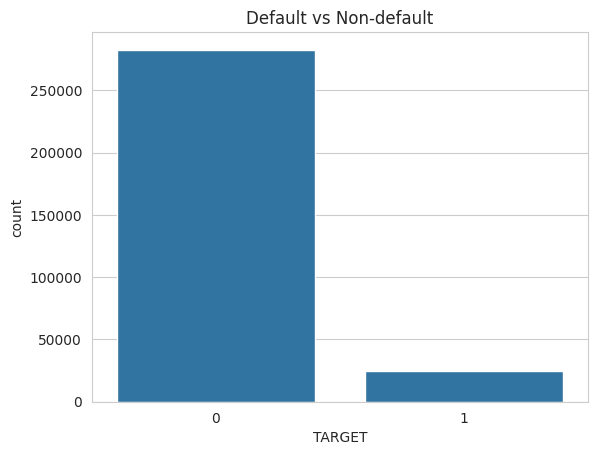

In [47]:
print(df["TARGET"].value_counts(normalize=True) * 100)
sns.countplot(x="TARGET", data=df)
plt.title("Default vs Non-default")
plt.show()

##4. Univariate Analysis

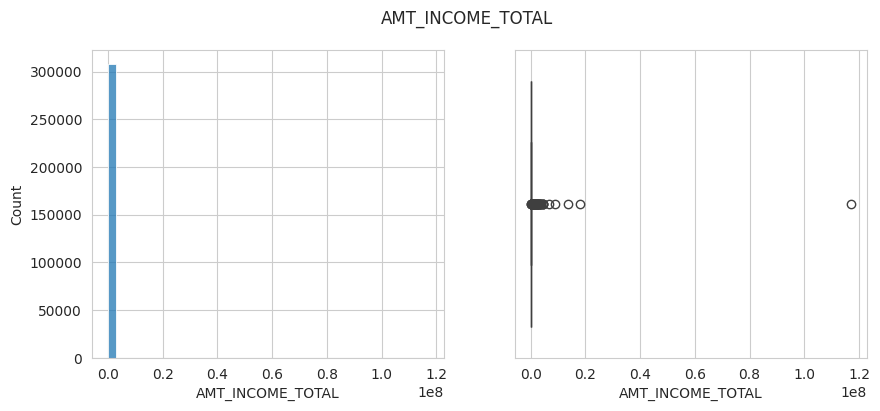

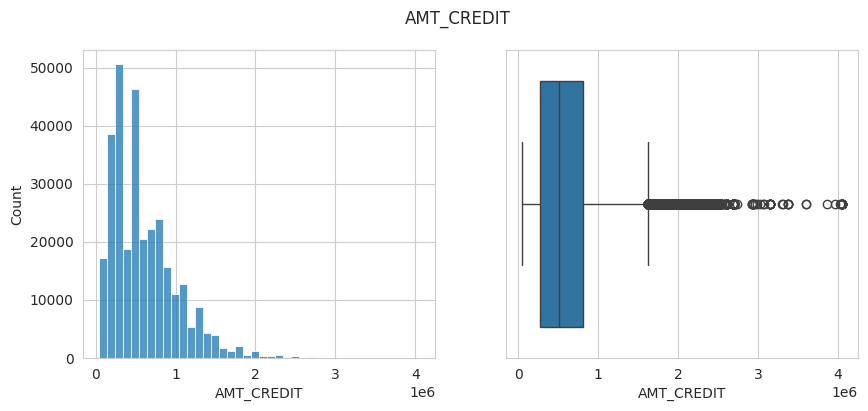

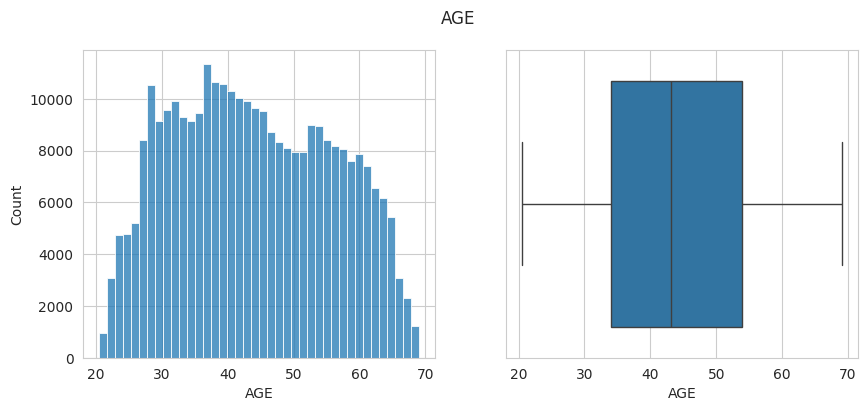

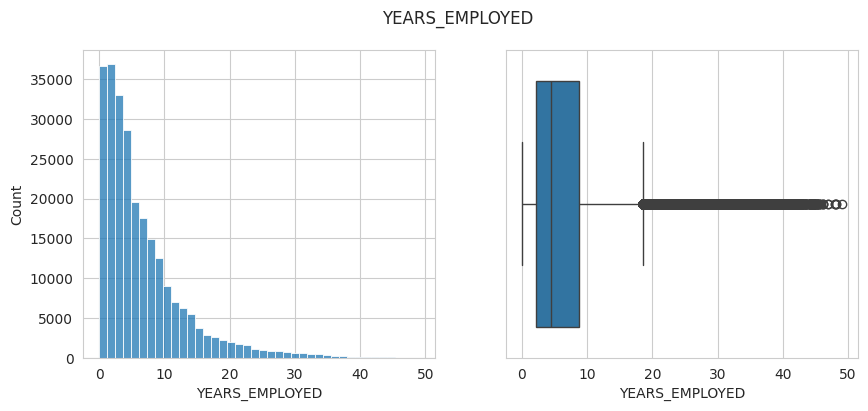

In [48]:
num_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AGE", "YEARS_EMPLOYED"]
for c in num_cols:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); sns.histplot(df[c].dropna(), bins=40)
    plt.subplot(1, 2, 2); sns.boxplot(x=df[c])
    plt.suptitle(c); plt.show()

In [49]:
df["AMT_INCOME_TOTAL"] = df["AMT_INCOME_TOTAL"].clip(upper=df["AMT_INCOME_TOTAL"].quantile(0.99))

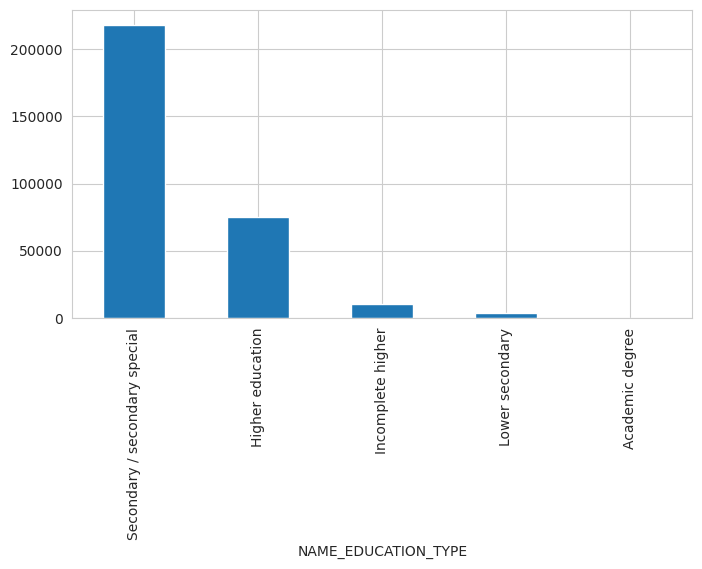

In [50]:
plt.figure(figsize=(8, 4))
df["NAME_EDUCATION_TYPE"].value_counts().plot(kind="bar")
plt.show()

##5. Bivariate Analysis

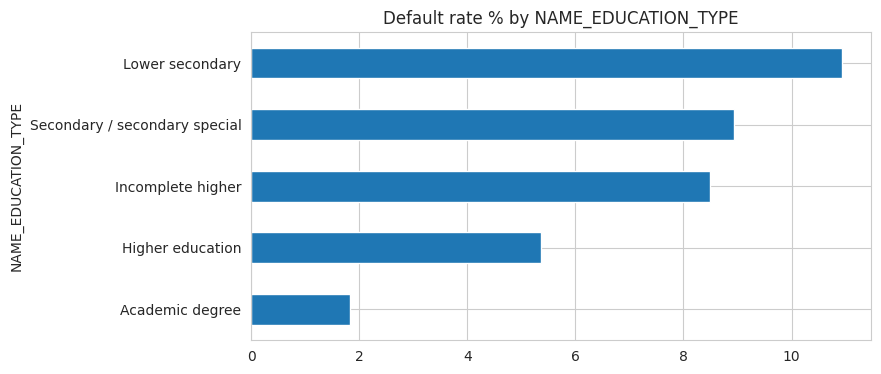

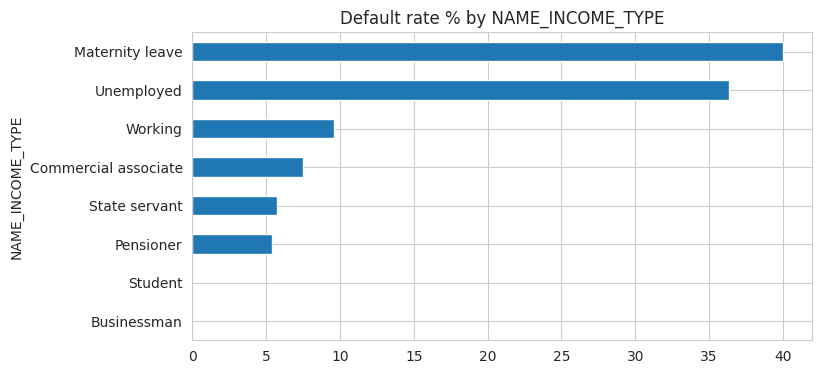

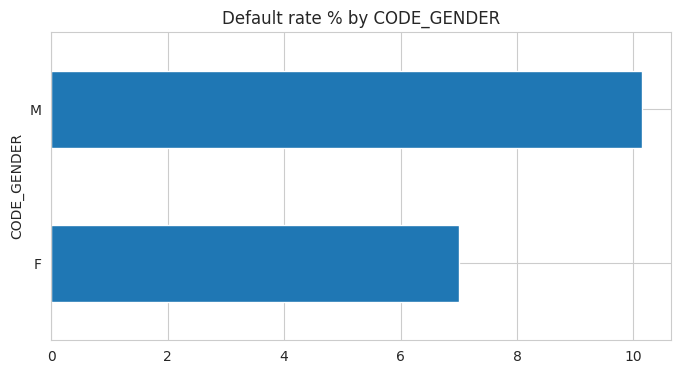

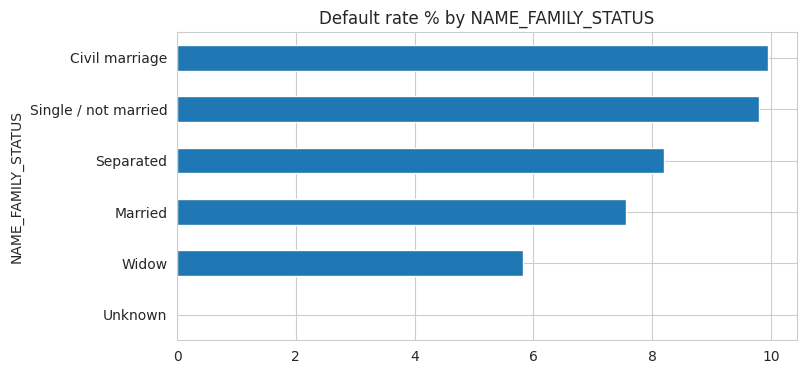

In [51]:
for c in ["NAME_EDUCATION_TYPE", "NAME_INCOME_TYPE", "CODE_GENDER", "NAME_FAMILY_STATUS"]:
    rate = df.groupby(c)["TARGET"].mean().sort_values() * 100
    rate.plot(kind="barh", figsize=(8, 4), title=f"Default rate % by {c}")
    plt.show()

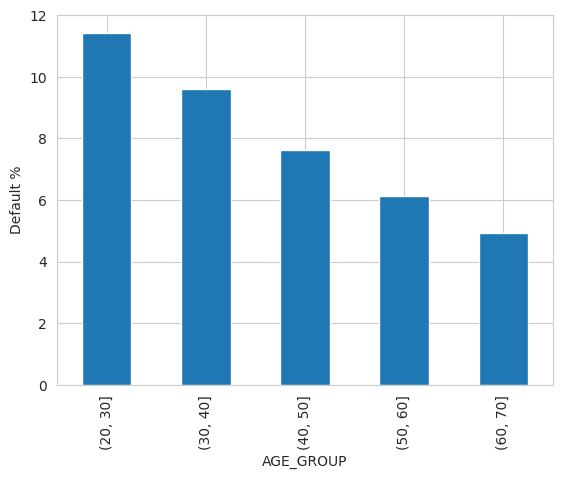

In [52]:
df["AGE_GROUP"] = pd.cut(df["AGE"], bins=[20, 30, 40, 50, 60, 70])
df.groupby("AGE_GROUP", observed=True)["TARGET"].mean().mul(100).plot(kind="bar")
plt.ylabel("Default %"); plt.show()

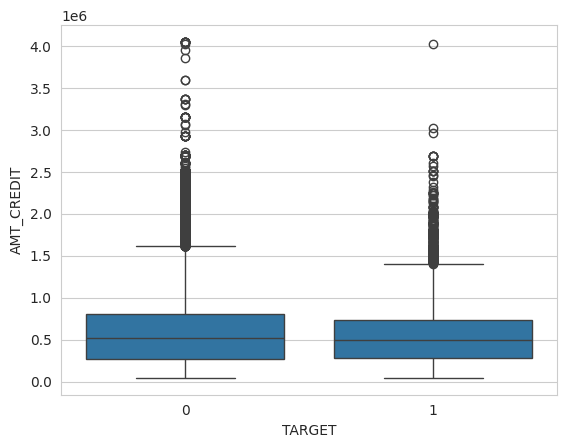

In [53]:
sns.boxplot(x="TARGET", y="AMT_CREDIT", data=df)
plt.show()

##6. Feature Engineering

/tmp/ipykernel_3489/3890858733.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["CREDIT_INCOME_RATIO"], 5))["TARGET"].mean().mul(100).plot(kind="bar")


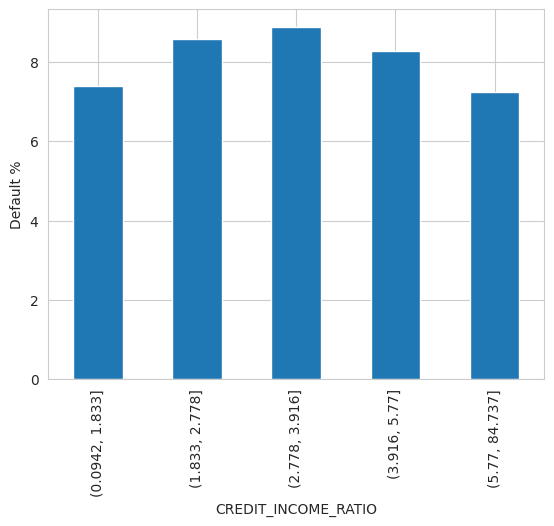

In [54]:
df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]

df.groupby(pd.qcut(df["CREDIT_INCOME_RATIO"], 5))["TARGET"].mean().mul(100).plot(kind="bar")
plt.ylabel("Default %"); plt.show()

##7. Correlation Analysis

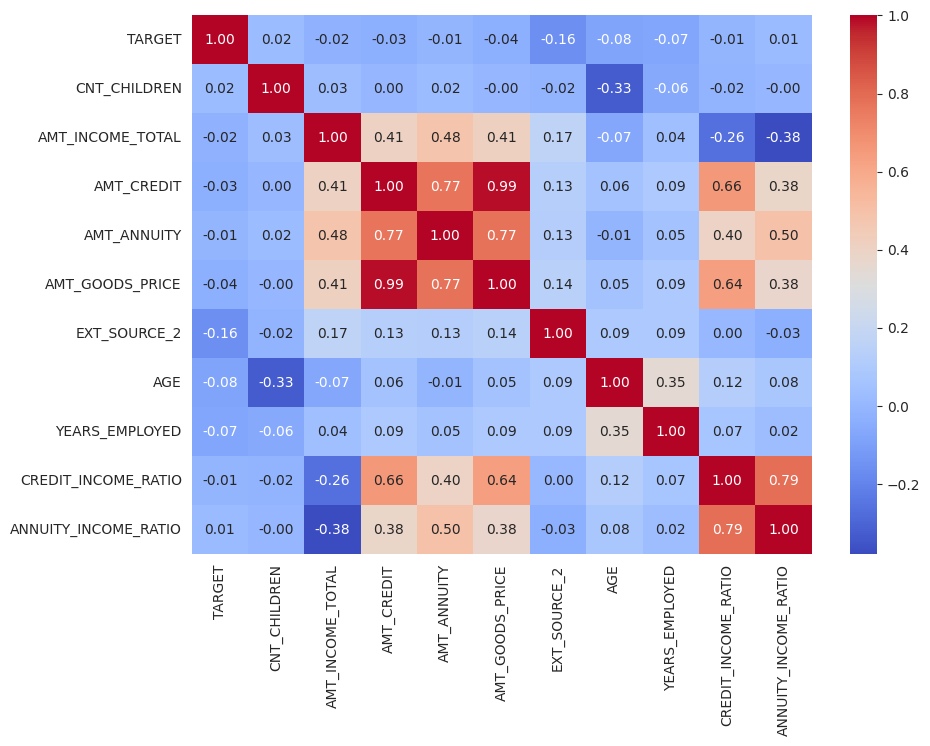

,TARGET
EXT_SOURCE_2,-0.160294
AGE,-0.078240
YEARS_EMPLOYED,-0.074960
AMT_GOODS_PRICE,-0.039625
AMT_CREDIT,-0.030371
AMT_INCOME_TOTAL,-0.023291
AMT_ANNUITY,-0.012817
CREDIT_INCOME_RATIO,-0.008059
ANNUITY_INCOME_RATIO,0.013852
CNT_CHILDREN,0.019189


In [55]:
corr = df.select_dtypes("number").corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

corr["TARGET"].sort_values()

In [56]:
# Overall default rate
print("Default rate:", round(df["TARGET"].mean() * 100, 2), "%")

# TARGET se correlation (sorted)
print(df.select_dtypes("number").corr()["TARGET"].sort_values())

# Age group ke hisaab se default
print(df.groupby("AGE_GROUP", observed=True)["TARGET"].mean().mul(100).round(2))

# Education ke hisaab se default
print(df.groupby("NAME_EDUCATION_TYPE")["TARGET"].mean().mul(100).round(2).sort_values())

# Income type ke hisaab se default
print(df.groupby("NAME_INCOME_TYPE")["TARGET"].mean().mul(100).round(2).sort_values())

Default rate: 8.07 %
EXT_SOURCE_2           -0.160294
AGE                    -0.078240
YEARS_EMPLOYED         -0.074960
AMT_GOODS_PRICE        -0.039625
AMT_CREDIT             -0.030371
AMT_INCOME_TOTAL       -0.023291
AMT_ANNUITY            -0.012817
CREDIT_INCOME_RATIO    -0.008059
ANNUITY_INCOME_RATIO    0.013852
CNT_CHILDREN            0.019189
TARGET                  1.000000
Name: TARGET, dtype: float64
AGE_GROUP
(20, 30]    11.43
(30, 40]     9.59
(40, 50]     7.63
(50, 60]     6.12
(60, 70]     4.93
Name: TARGET, dtype: float64
NAME_EDUCATION_TYPE
Academic degree                   1.83
Higher education                  5.36
Incomplete higher                 8.49
Secondary / secondary special     8.94
Lower secondary                  10.93
Name: TARGET, dtype: float64
NAME_INCOME_TYPE
Businessman              0.00
Student                  0.00
Pensioner                5.39
State servant            5.75
Commercial associate     7.48
Working                  9.59
Unemployed       

## Key Findings

1. **Class imbalance:** Sirf ~8.07% applicants ne default kiya, baaki 91.93% ne loan chuka diya.
2. **EXT_SOURCE_2 sabse strong predictor hai:** TARGET se correlation -0.160294, yaani score kam to default chance zyada.
3. **Age aur job stability:** AGE (-0.078240) aur YEARS_EMPLOYED (-0.074960) ke saath halka negative relation hai. Kam umar aur kam job experience wale zyada default karte hain.
4. **Credit-to-income ratio ka relation linear nahi hai:** Default rate middle groups mein sabse zyada (~8.5-9%) aur dono extremes mein ~7.2-7.4% hai.
5. **Duplicate features:** AMT_CREDIT aur AMT_GOODS_PRICE ka correlation 0.99 hai, modelling mein ek hi rakhna chahiye.
6. (Education / income type / age group wale charts se apni findings yahan add karo)

## Recommendations

1. Loan approval mein EXT_SOURCE_2 jaise external credit score ko sabse zyada weight dena chahiye.
2. Kam umar aur kam job experience wale applicants ki extra verification karni chahiye.
3. Credit-to-income ratio ko akele use na karke loan type ke saath dekhna chahiye.
4. Modelling se pehle correlated features (AMT_CREDIT / AMT_GOODS_PRICE) mein se ek hata do.
5. Data imbalanced hai, isliye accuracy ki jagah Recall, Precision aur ROC-AUC use karo.

## Conclusion
Is EDA se pata chala ki default risk kisi ek factor se nahi, balki credit score, age, job stability aur loan structure ke combination se juda hai.

## Limitations
- Analysis sirf application_train.csv par hai (baaki tables jaise bureau, previous_application use nahi hue).
- Correlation ka matlab causation nahi hota.
- Sirf 18 columns select kiye gaye the.